# V2: Evaluation
## 5.1 Loading the Best Model
### Training Configuration

- Random seed: 42
- Batch size: 32
- Embedding dimension: 128
- Optimizer: Adam
- Learning rate: 0.001
- Epochs: 15
- Checkpoint criterion: Lowest validation loss

In [1]:
from src.v2.train import BugFixClassifier
from torch.utils.data import DataLoader
from src.v2.data import BugFixDataset, collate_batch
import torch
import pandas as pd
import torch.nn as nn
import json

with open('data/processed/token_to_id.json', 'r') as f:
    token_to_id = json.load(f)

with open('data/processed/label_to_id.json', 'r') as f:
    label_to_id = json.load(f)

model = BugFixClassifier(vocab_size=len(token_to_id), embedding_dimension=128, num_classes=len(label_to_id), padding_index=token_to_id['<PAD>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

checkpoint = torch.load('models/v2_best_model.pt', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['validation_loss']

best_epoch = checkpoint['epoch']
best_validation_loss = checkpoint['validation_loss']

print(f'Best Epoch: {best_epoch}')
print(f'Best Validation Loss: {best_validation_loss}')

validation_dataset = BugFixDataset(pd.read_parquet('data/processed/validation_v2_label_id.parquet'))
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

Best Epoch: 13
Best Validation Loss: 0.5283811876131279


## 5.2 Testing the Model

In [2]:
from src.v2.evaluate import evaluate_model
from sklearn.metrics import classification_report
import json

accuracy, average_loss, all_predictions, all_labels = evaluate_model(model, criterion, validation_loader)

assert len(all_predictions) == len(validation_dataset)
assert len(all_labels) == len(validation_dataset)

with open('data/processed/id_to_label.json', 'r') as file:
    id_to_label = json.load(file)

print(id_to_label)
print()

class_names = [id_to_label[str(i)] for i in range(len(id_to_label))]
print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))


{'0': 'assignment', '1': 'call', '2': 'control_flow', '3': 'expression', '4': 'identifier'}

              precision    recall  f1-score   support

  assignment     0.7149    0.7071    0.7110       734
        call     0.8318    0.8736    0.8522      2746
control_flow     0.8879    0.8899    0.8889       863
  expression     0.6020    0.5569    0.5786      1187
  identifier     0.6923    0.5202    0.5941       173

    accuracy                         0.7780      5703
   macro avg     0.7458    0.7095    0.7249      5703
weighted avg     0.7732    0.7780    0.7748      5703



## 5.3 Counting the Rows for Identifier

In [3]:
train_dataset = pd.read_parquet('data/processed/train_v2_label_id.parquet')
print(f'Total Amount of Examples in Train: {len(train_dataset)}')
print(f'Amount of Identifer Examples: {len(train_dataset[train_dataset['top_level_label'] == 'identifier'])}')
print(f'Percentage of Identifier Examples in Train Dataset: {len(train_dataset[train_dataset['top_level_label'] == 'identifier']) / len(train_dataset) * 100:.4f}')

Total Amount of Examples in Train: 22809
Amount of Identifer Examples: 692
Percentage of Identifier Examples in Train Dataset: 3.0339


## 5.4 Confusion Matrix Heatmap

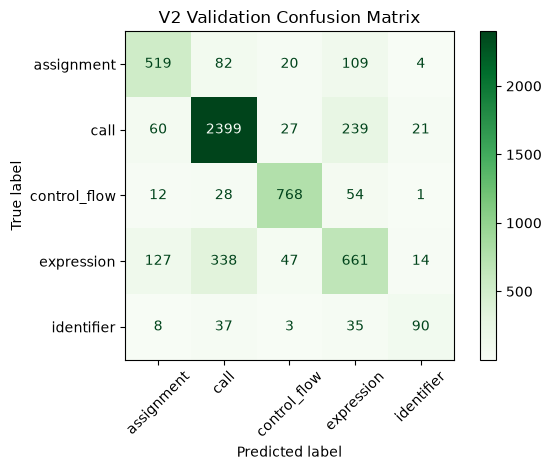

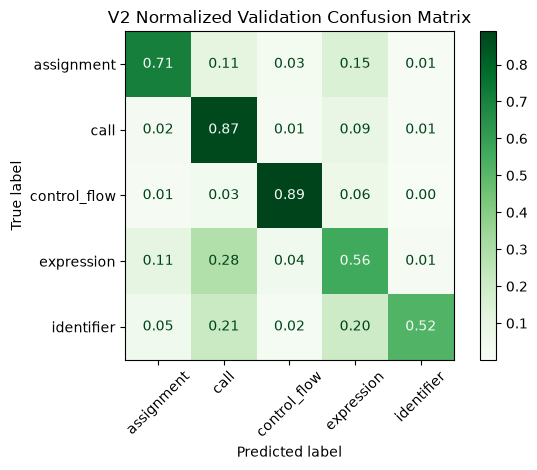

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)))
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)

display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V2 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

normalized_confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)), normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=normalized_confusion, display_labels=class_names)

display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V2 Normalized Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 5.4 V2 Validation Error Analysis:
- **Strongest Class**: `Control_Flow`
- **Common Confusion**: There was some confusion between expression and call and vise-versa
- **Identifier** made the most mistakes with most mistakes going to call and expression
- Due to an **imbalance** in the class, the weighted score is much higher in comparison to the macro F1 score.

## 5.5 Retraining the V1 Model and Evaluating on Validation Set Only
- I decided to retrain and compare both on the train and evaluate on the validation set because it was unfair to test the v2 model on the validation set and not do the same for the v1 model.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

train = pd.read_csv('data/processed/train_v2.csv')
validation = pd.read_csv('data/processed/validation_v2.csv')
X_train_raw = train['diff']
X_validation_raw = validation['diff']
y_train = train['top_level_label']
y_validation = validation['top_level_label']

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_validation = vectorizer.transform(X_validation_raw)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = LogisticRegression(max_iter= 1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_validation)

accuracy = accuracy_score(y_validation, lr_predictions)
print(f"Accuracy: {accuracy:.4f}")

cf_mat = confusion_matrix(y_validation, lr_predictions, labels=lr_model.classes_)
print("Classes:", lr_model.classes_)
print("Confusion Matrix:")
print(cf_mat)

report = classification_report(y_validation, lr_predictions, digits=4)
print(f'Report: {report}')

Accuracy: 0.7058
Classes: ['assignment' 'call' 'control_flow' 'expression' 'identifier']
Confusion Matrix:
[[ 555  114   18   45    2]
 [ 104 2431   24  174   13]
 [  30   39  741   53    0]
 [ 268  601   50  259    9]
 [  71   52    3    8   39]]
Report:               precision    recall  f1-score   support

  assignment     0.5399    0.7561    0.6300       734
        call     0.7510    0.8853    0.8126      2746
control_flow     0.8864    0.8586    0.8723       863
  expression     0.4805    0.2182    0.3001      1187
  identifier     0.6190    0.2254    0.3305       173

    accuracy                         0.7058      5703
   macro avg     0.6554    0.5887    0.5891      5703
weighted avg     0.6840    0.7058    0.6769      5703



## 5.6 Confusion Matrix Heatmap (V1)

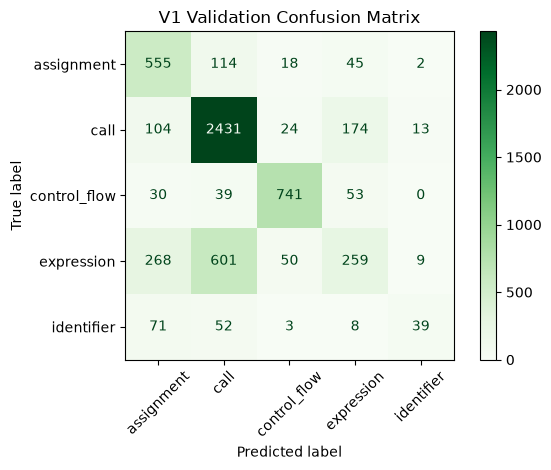

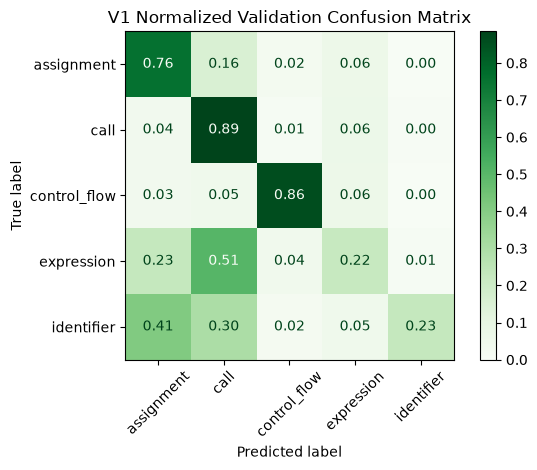

In [7]:
confusion = confusion_matrix(y_validation, lr_predictions, labels=class_names)
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)

display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V1 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

normalized_confusion = confusion_matrix(y_validation, lr_predictions, labels=class_names, normalize='true')

display = ConfusionMatrixDisplay(confusion_matrix=normalized_confusion, display_labels=class_names)

display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V1 Normalized Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 5.7 Conclusion: V1 vs V2

### Overall Metrics:
- **Accuracy** improved by `7.22 percentage points` in V2
- **Macro F1** improved by `13.58 percentage points` in V2
- **Weighted F1** improved by `9.79 percentage points` in V2

### Class-Level Performance:
- V2 improved the most in the expression and the identifier classes and made some improvement to the assignment class and even smaller improvements to the call and control flow class.
- There were small tradeoffs in V2. The assignment recall fell from `75.6%` to `70.7%` and the call recall fell from `88.5%` to `87.4%`. Their F1 scores still improved because V2 made large increases to the precision scores.

### Confusion Patterns:
- Despite the increase in the scores for expression and identifier, both classes still suffered low scores in comparison to the high scores for the classes: `control flow and call`
- Expression -> call decreased from `50.6%` in V1 to `28.5%` in V2
- Expression recall increased from `21.8%` to `55.7%`
- Identifier recall increased from `22.5%` to `52.0%`

### Conclusion:
Because V2 uses mean pooling, it considers token content but does not preserve token order. Its largest improvements occurred in expression and identifier, although these remained its weakest classes. This is consistent with the hypothesis that these classes require relationships and sequence context that V2 cannot represent. V3 can test this hypothesis by introducing an architecture that models token order.